In [4]:
import zipfile

with zipfile.ZipFile("archive.zip", "r") as zip_ref:
    zip_ref.extractall("data")

print("Dataset extracted successfully!")

Dataset extracted successfully!


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

score = pd.read_csv("data/student-scores.csv")
print(score)

        id first_name last_name  ... biology_score english_score  geography_score
0        1       Paul     Casey  ...            63            80               87
1        2   Danielle  Sandoval  ...            90            88               90
2        3       Tina   Andrews  ...            65            77               94
3        4       Tara     Clark  ...            89            63               86
4        5    Anthony    Campos  ...            80            74               76
...    ...        ...       ...  ...           ...           ...              ...
1995  1996       Alan  Reynolds  ...            75            84               82
1996  1997     Thomas   Gilbert  ...            87            67               73
1997  1998    Madison     Cross  ...            68            94               78
1998  1999   Brittany   Compton  ...            95            88               75
1999  2000    Natalie     Smith  ...            83            93              100

[2000 rows x 17

In [6]:
score.head()

,id,first_name,last_name,email,gender,part_time_job,absence_days,extracurricular_activities,weekly_self_study_hours,career_aspiration,math_score,history_score,physics_score,chemistry_score,biology_score,english_score,geography_score
0,1,Paul,Casey,paul.casey.1@gslingacademy.com,male,False,3,False,27,Lawyer,73,81,93,97,63,80,87
1,2,Danielle,Sandoval,danielle.sandoval.2@gslingacademy.com,female,False,2,False,47,Doctor,90,86,96,100,90,88,90
2,3,Tina,Andrews,tina.andrews.3@gslingacademy.com,female,False,9,True,13,Government Officer,81,97,95,96,65,77,94
3,4,Tara,Clark,tara.clark.4@gslingacademy.com,female,False,5,False,3,Artist,71,74,88,80,89,63,86
4,5,Anthony,Campos,anthony.campos.5@gslingacademy.com,male,False,5,False,10,Unknown,84,77,65,65,80,74,76


In [7]:
score.shape
score.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 17 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   id                          2000 non-null   int64 
 1   first_name                  2000 non-null   object
 2   last_name                   2000 non-null   object
 3   email                       2000 non-null   object
 4   gender                      2000 non-null   object
 5   part_time_job               2000 non-null   bool  
 6   absence_days                2000 non-null   int64 
 7   extracurricular_activities  2000 non-null   bool  
 8   weekly_self_study_hours     2000 non-null   int64 
 9   career_aspiration           2000 non-null   object
 10  math_score                  2000 non-null   int64 
 11  history_score               2000 non-null   int64 
 12  physics_score               2000 non-null   int64 
 13  chemistry_score             2000 non-null   int6

In [8]:
score.isnull().sum()

id                            0
first_name                    0
last_name                     0
email                         0
gender                        0
part_time_job                 0
absence_days                  0
extracurricular_activities    0
weekly_self_study_hours       0
career_aspiration             0
math_score                    0
history_score                 0
physics_score                 0
chemistry_score               0
biology_score                 0
english_score                 0
geography_score               0
dtype: int64

In [15]:
score = score.drop(columns = ["id", "first_name", "last_name", "email"])

In [16]:
print(score.columns)

Index(['gender', 'part_time_job', 'absence_days', 'extracurricular_activities',
       'weekly_self_study_hours', 'career_aspiration', 'math_score',
       'history_score', 'physics_score', 'chemistry_score', 'biology_score',
       'english_score', 'geography_score'],
      dtype='object')


In [ ]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()

X = score.drop(columns = ["math_score"])
y = score["math_score"]
X = pd.get_dummies(X)
print(X)
model.fit(X, y)

      part_time_job  ...  career_aspiration_Writer
0             False  ...                     False
1             False  ...                     False
2             False  ...                     False
3             False  ...                     False
4             False  ...                     False
...             ...  ...                       ...
1995          False  ...                     False
1996          False  ...                     False
1997          False  ...                     False
1998           True  ...                     False
1999          False  ...                     False

[2000 rows x 29 columns]


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [18]:
predictions = model.predict(X)
print(predictions)

[85.83667366 92.87564348 79.91947337 ... 93.80772093 69.34584978
 88.46289529]


In [19]:
comparison = pd.DataFrame({
    "Actual": y,
    "Predicted": predictions
})

print(comparison.head(10))

   Actual  Predicted
0      73  85.836674
1      90  92.875643
2      81  79.919473
3      71  79.659405
4      84  79.790107
5      93  81.586877
6      99  89.864808
7      95  90.312988
8      94  79.221676
9      98  76.192141


In [20]:
from sklearn.metrics import mean_squared_error, r2_score
mse = mean_squared_error(y, predictions)
r2 = r2_score(y, predictions)
print(f"Mean Squared Error: {mse}")
print(f"R^2 Score: {r2}")

Mean Squared Error: 116.41490466934486
R^2 Score: 0.33405159219007474


In [21]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [24]:
predictions = model.predict(X_test)
print(predictions)

[87.24247882 90.17952857 78.82338549 76.29529117 90.03652894 91.49750067
 85.45917654 85.66335091 69.32413141 89.73777647 79.1205685  80.15426712
 80.80011214 85.52251892 77.51260592 91.73916692 67.0397452  79.31746655
 90.3580361  92.29632378 90.10135747 87.30544712 92.84553579 85.76389124
 91.29148964 91.48194459 92.20593984 80.26333771 79.46135521 88.43439028
 77.23562945 91.72897958 88.23983474 70.61566804 92.08237327 80.46768359
 79.87382136 81.36023064 92.66451618 79.88347421 78.82004329 86.25534408
 81.67824294 92.54622356 80.31742058 89.07621275 91.50602585 93.39840037
 81.08371049 93.16212081 68.74016129 89.41284342 78.89735648 69.91975693
 92.682561   90.81755813 85.77615872 68.3239522  78.43025079 93.9131747
 89.45349448 70.78912547 69.63822816 86.38832957 82.5777529  85.26938494
 70.12718884 78.47370487 67.36843401 69.80094164 86.57552852 79.50485536
 89.73521208 79.93592119 87.19945541 79.21843952 92.69120829 68.85898421
 69.09004664 90.59713815 84.81405601 68.95007642 68.

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score

mse = mean_squared_error(y_test, predictions)
r2 = r2_score(y_test, predictions)
print("MSE:", mse)
print("R2:", r2)

MSE: 121.96282615152074
R2: 0.2650415272932799


In [26]:
comparison = pd.DataFrame({
    "Actual": y_test,
    "Predicted": predictions
})
print(comparison.head(10))

      Actual  Predicted
1860      97  87.242479
353       85  90.179529
1333      80  78.823385
905       57  76.295291
1289      86  90.036529
1273      99  91.497501
938       98  85.459177
1731      87  85.663351
65        90  69.324131
1323      92  89.737776


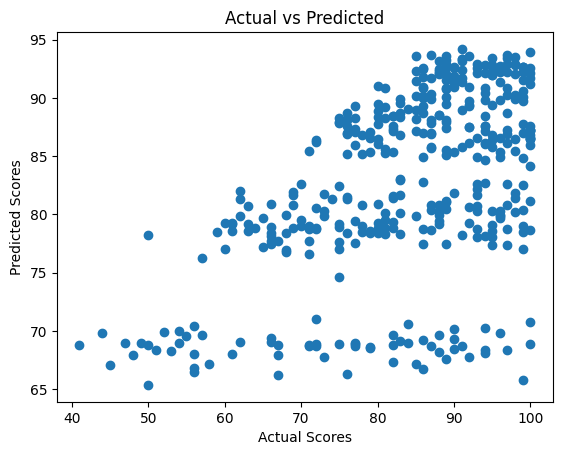

In [27]:
plt.scatter(y_test, predictions)
plt.xlabel("Actual Scores")
plt.ylabel("Predicted Scores")
plt.title("Actual vs Predicted")

plt.show()